# Machine Learning Final Project

**Author:** Murad  
**Course:** Machine Learning  
**Academic Year:** 2025–2026  

---

## 0. Setup and Data Loading

---

## 1. Dataset Exploration

### 1.1 Dataset Overview
- Number of samples
- Number of features
- Feature types

### 1.2 Target Variable Analysis
- Class distribution
- Balance / imbalance

### 1.3 Missing Values Analysis
- Missing value counts
- Strategy for handling missing data

---

## 2. Data Preprocessing

### 2.1 Train / Test Split
- Splitting strategy
- Stratification

### 2.2 Preprocessing Pipelines
- Numerical features
- Categorical features

### 2.3 Preprocessing Validation
- Checking transformed data
- No data leakage

---

## 3. Exploratory Data Analysis (EDA)

### 3.1 Numerical Features vs Target
- Correlation analysis
- Distribution comparison

### 3.2 Categorical Features vs Target
- Target rate by category

### 3.3 Key Insights from EDA

---

## 4. Feature Engineering

### 4.1 Creation of New Features
- Ratios
- Differences
- Aggregations

### 4.2 Evaluation of Engineered Features

---

## 5. Modeling and Evaluation

### 5.1 Baseline Model
- Logistic Regression

### 5.2 Ensemble Models
- Random Forest
- Gradient Boosting
- AdaBoost

### 5.3 Model Comparison
- Evaluation metrics
- Model selection

---

## 6. Hyperparameter Tuning

### 6.1 Model Selection for Tuning

### 6.2 Hyperparameter Optimization
- RandomizedSearchCV

### 6.3 Performance Improvement Analysis

---

## 7. Model Interpretation

### 7.1 Feature Importance

### 7.2 SHAP Analysis

---

## 8. Conclusions and Recommendations

### 8.1 Final Model Summary

### 8.2 Business Insights

### 8.3 Limitations and Future Work


## PHASE 0 - Setup and Data Loading

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn core
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score


plt.style.use("default")
sns.set_theme()


In [2]:
os.getcwd()


'D:\\UNIME\\Anaconda'

In [3]:
# Load Dataset
df = pd.read_csv("final_project_dataset_complete.csv")

#Preview first rows
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,category_1,category_2,target
0,0.496714,1.146509,-0.648521,0.833005,0.784920,-2.209437,-1.300105,-2.242241,Above Average,Region C,1
1,-0.138264,-0.061846,NaN,0.403768,0.704674,-2.498565,-1.339227,-1.942298,Below Average,Region A,0
2,0.647689,1.395115,-0.764126,1.708266,-0.250029,1.956259,1.190238,1.503559,High,Region C,1
3,1.523030,2.657560,-2.461653,2.649051,0.882201,3.445638,2.120913,3.409035,High,Region B,1
4,-0.234153,-0.499391,0.576097,-0.441656,0.610601,0.211425,0.935759,-0.401463,Below Average,Region C,0


This dataset contains numerical and categorical features along with a binary target variable.

## PHASE 1.0 - Dataset Exploration


### 1.1 Dataset Overview 

In [4]:
# Dataset shape
df.shape

(9000, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_1   9000 non-null   float64
 1   feature_2   9000 non-null   float64
 2   feature_3   8600 non-null   float64
 3   feature_4   9000 non-null   float64
 4   feature_5   9000 non-null   float64
 5   feature_6   8500 non-null   float64
 6   feature_7   9000 non-null   float64
 7   feature_8   9000 non-null   float64
 8   category_1  9000 non-null   object 
 9   category_2  9000 non-null   object 
 10  target      9000 non-null   int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 773.6+ KB


In [6]:
df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,target
count,9000.000000,9000.000000,8600.000000,9000.000000,9000.000000,8500.000000,9000.000000,9000.000000,9000.000000
mean,0.000427,0.003349,0.003235,-0.008481,-0.002177,-0.006447,0.000592,0.003348,0.475444
std,1.241318,2.508324,1.542901,2.061784,0.577415,1.981615,1.075064,2.043643,0.499424
min,-18.665400,-37.852816,-6.676680,-8.190124,-0.999791,-8.590782,-4.422265,-9.474989,0.000000
25%,-0.680062,-1.382610,-1.022085,-1.399928,-0.502614,-1.329040,-0.700078,-1.356620,0.000000
50%,-0.003938,-0.016698,0.005196,-0.019541,0.001695,-0.003137,-0.000097,-0.007584,0.000000
75%,0.680513,1.380228,1.038571,1.394151,0.497004,1.324897,0.731942,1.402024,1.000000
max,21.934496,47.603454,6.203055,8.189001,0.999914,6.803751,3.857219,7.572578,1.000000


In [7]:
# Separate feature types
numeric_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = df.select_dtypes(include=["object"]).columns.tolist()

numeric_features, categorical_features


(['feature_1',
  'feature_2',
  'feature_3',
  'feature_4',
  'feature_5',
  'feature_6',
  'feature_7',
  'feature_8',
  'target'],
 ['category_1', 'category_2'])

The dataset contains 9000 observations and 11 features.
Most features are numerical, with two categorical variables.
The target variable is binary.
At this stage we only perform structural exploration, without modifying the data.

### 1.2 Target Variable Analysis

In this section we analyze the distribution of the target variable to check whether the dataset is balanced or imbalanced.


In [8]:
# Target distributions (absolute values)
df["target"].value_counts()

target
0    4721
1    4279
Name: count, dtype: int64

In [9]:
# Target distributions (percentage)
df["target"].value_counts(normalize=True) * 100

target
0    52.455556
1    47.544444
Name: proportion, dtype: float64

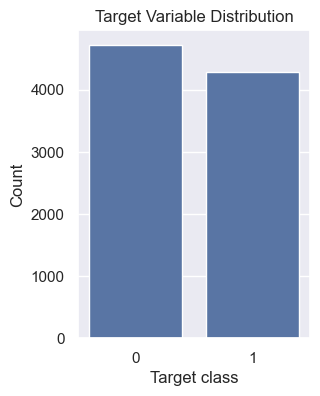

In [10]:
plt.figure(figsize=(3, 4))
sns.countplot(x="target", data=df)
plt.title("Target Variable Distribution")
plt.xlabel("Target class")
plt.ylabel("Count")
plt.show()

**Observations:**

- The target variable is binary.
- The class distribution is relatively balanced.
- No severe class imbalance is observed, therefore no resampling techniques are required at this stage.


### 1.3 Missing Values Analysis
In this section we analyze the presence of missing values and define an appropriate strategy to handle them.

In [11]:
# Count missing values per column 
missing_counts = df.isnull().sum()
missing_counts

feature_1       0
feature_2       0
feature_3     400
feature_4       0
feature_5       0
feature_6     500
feature_7       0
feature_8       0
category_1      0
category_2      0
target          0
dtype: int64

In [12]:
# Percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage

feature_1     0.000000
feature_2     0.000000
feature_3     4.444444
feature_4     0.000000
feature_5     0.000000
feature_6     5.555556
feature_7     0.000000
feature_8     0.000000
category_1    0.000000
category_2    0.000000
target        0.000000
dtype: float64

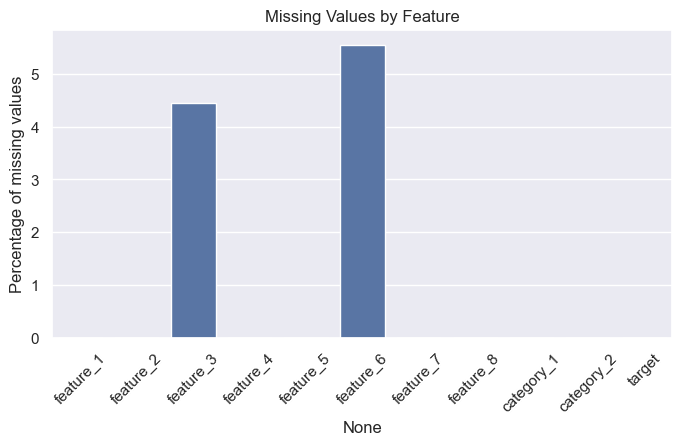

In [13]:
plt.figure(figsize=(8, 4))
sns.barplot(
    x=missing_percentage.index,
    y=missing_percentage.values
)
plt.xticks(rotation=45)
plt.ylabel("Percentage of missing values")
plt.title("Missing Values by Feature")
plt.show()

**Observations:**

- Missing values are present only in a small number of numerical features.
- The percentage of missing data is low.
- Therefore, instead of dropping observations, we will apply imputation techniques.
- Median imputation is selected as it is robust to outliers.


## 2. Data Preprocessing

### 2.1 Train / Test Split

In this section we split the dataset into training and test sets to evaluate model performance on unseen data.


In [14]:
# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [16]:
# Check shapes
X_train.shape, X_test.shape


((7200, 10), (1800, 10))

**Explanation:**

- The dataset is split into 80% training and 20% test data.
- Stratified splitting is applied to preserve the original class distribution.
- The test set is kept completely unseen during model training.


### 2.2 Preprocessing Pipelines

In this section we define preprocessing pipelines for numerical and categorical features and combine them using a ColumnTransformer.


In [17]:
# Identify numerical and categorical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_features, ategoricalc_features


(['feature_1',
  'feature_2',
  'feature_3',
  'feature_4',
  'feature_5',
  'feature_6',
  'feature_7',
  'feature_8'],
 ['category_1', 'category_2'])

In [18]:
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [19]:
categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


In [20]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


**Explanation:**

- Numerical features are imputed using the median and scaled.
- Categorical features are encoded using One-Hot Encoding.
- ColumnTransformer allows applying different preprocessing steps to different feature types.
- All preprocessing steps will be learned only from the training data to avoid data leakage.


### 2.3 Preprocessing Validation

In this section we validate the preprocessing pipeline by fitting it on the training set and applying the same transformations to the test set.


In [21]:
# Fit preprocessing on training data and transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape


((7200, 15), (1800, 15))

In [22]:
# Number of features after preprocessing
X_train_processed.shape[1]


15

### Preprocessing Validation

- The preprocessing pipeline is fitted only on the training set.
- The same transformations are applied to the test set.
- This approach prevents data leakage and ensures fair model evaluation.


### 3.1 Numeric Features vs Target

This section explores the relationship between numerical features and the target variable in order to identify potentially important predictors.


In [23]:
# Numeric feature columns (exclude target)
numeric_cols = [c for c in df.columns if c.startswith("feature_")]

# Correlation matrix for numeric features + target
corr_matrix = df[numeric_cols + ["target"]].corr()

# Correlation of each numeric feature with target (absolute value)
target_corr = corr_matrix["target"].drop("target").abs().sort_values(ascending=False)
target_corr



feature_3    0.704351
feature_4    0.694885
feature_2    0.606016
feature_1    0.605940
feature_5    0.007873
feature_8    0.004658
feature_7    0.002000
feature_6    0.001457
Name: target, dtype: float64

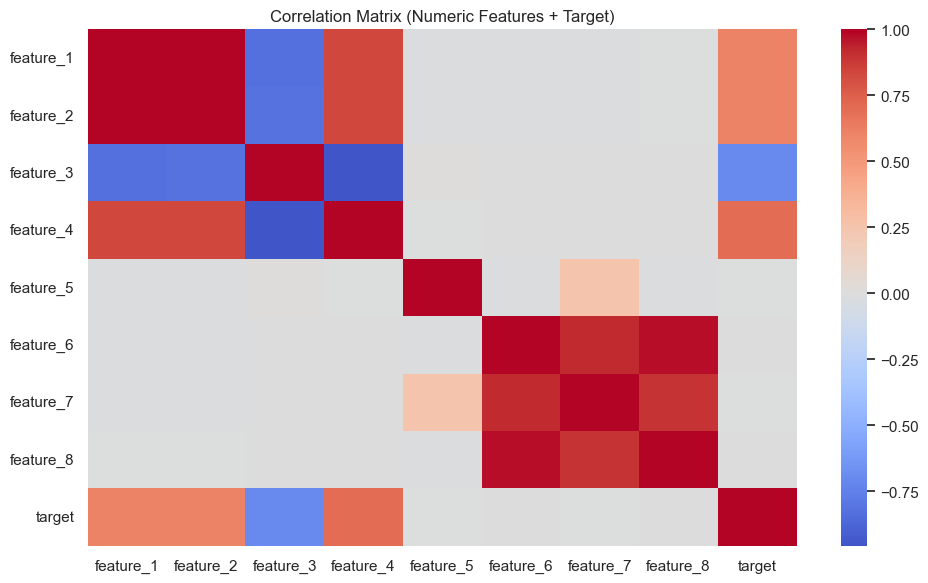

In [24]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix (Numeric Features + Target)")
plt.tight_layout()
plt.show()


In [25]:
top_features = target_corr.head(4).index.tolist()
top_features


['feature_3', 'feature_4', 'feature_2', 'feature_1']

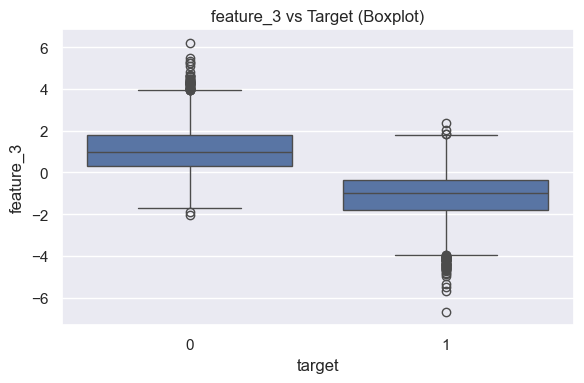

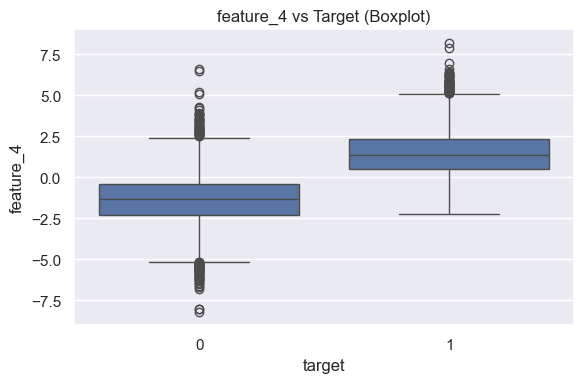

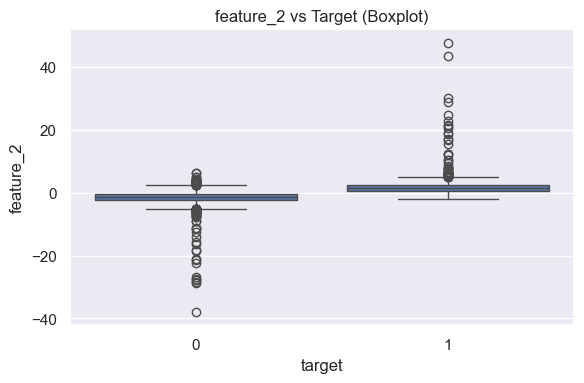

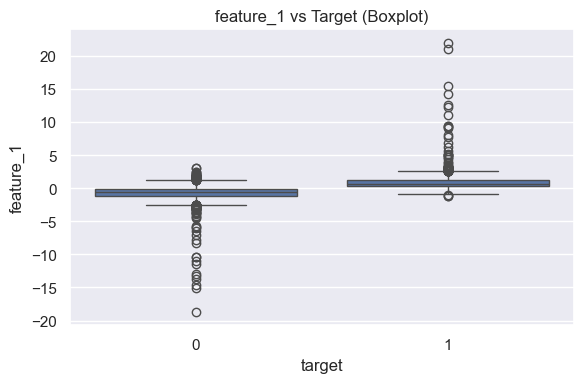

In [26]:
for col in top_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="target", y=col, data=df)
    plt.title(f"{col} vs Target (Boxplot)")
    plt.tight_layout()
    plt.show()


**Key findings (Numeric Features):**
- The correlation analysis shows that a small set of numerical features has the strongest association with the target.
- Boxplots indicate differences in central tendency (median) between classes for the top features.
- Distribution plots show shifted distributions across classes for some features, suggesting predictive signal.
- These features are good candidates for modeling and for potential feature engineering (e.g., ratios, interactions).


### 3.2 Categorical Features vs Target

This section analyzes the relationship between categorical features and the target variable by comparing target rates across categories.


In [27]:
# Categorical feature columns
categorical_cols = ["category_1", "category_2"]
categorical_cols


['category_1', 'category_2']

In [28]:
ct_cat1 = pd.crosstab(
    df["category_1"],
    df["target"],
    normalize="index"
)

ct_cat1


target,0,1
category_1,,
Above Average,0.329473,0.670527
Below Average,0.741218,0.258782
High,0.061889,0.938111
Low,0.968951,0.031049


In [29]:
ct_cat2 = pd.crosstab(
    df["category_2"],
    df["target"],
    normalize="index"
)

ct_cat2


target,0,1
category_2,,
Region A,0.524923,0.475077
Region B,0.518795,0.481205
Region C,0.535227,0.464773


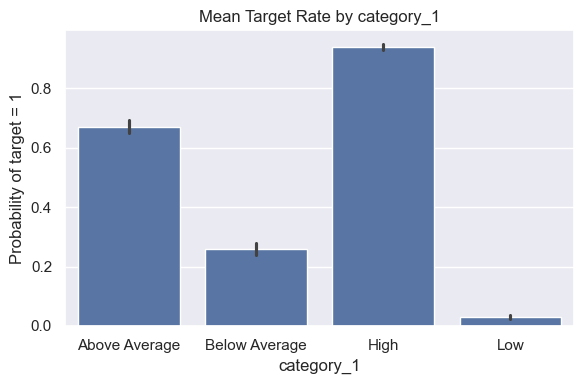

In [30]:
plt.figure(figsize=(6, 4))
sns.barplot(
    x="category_1",
    y="target",
    data=df,
    estimator=lambda x: sum(x)/len(x)
)
plt.title("Mean Target Rate by category_1")
plt.ylabel("Probability of target = 1")
plt.tight_layout()
plt.show()


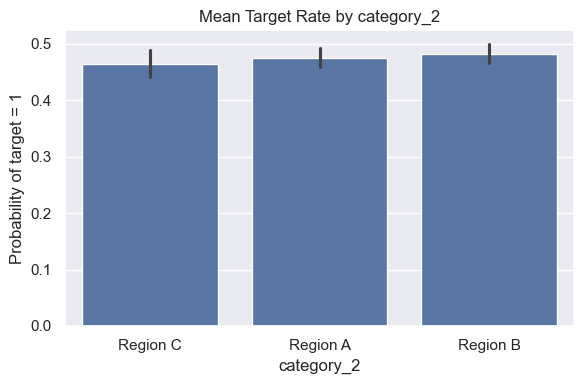

In [31]:
plt.figure(figsize=(6, 4))
sns.barplot(
    x="category_2",
    y="target",
    data=df,
    estimator=lambda x: sum(x)/len(x)
)
plt.title("Mean Target Rate by category_2")
plt.ylabel("Probability of target = 1")
plt.tight_layout()
plt.show()


**Key Findings (Categorical Features):**

- Some categories show higher target rates compared to others.
- Categorical features appear to provide useful information for predicting the target.
- These variables may contribute to model performance after proper encoding.


### 3.3 EDA Insights

This section summarizes the main findings from the exploratory data analysis and highlights insights relevant for feature engineering and modeling.


**Key Insights:**

- Several numerical features show meaningful correlation with the target variable, indicating potential predictive power.
- Boxplots reveal noticeable differences in median values of some numerical features between target classes.
- Distribution plots suggest partial separation between classes for selected numerical features.
- Certain categories in categorical variables are associated with higher target rates.
- Categorical features therefore provide additional information beyond numerical variables.
- These findings suggest opportunities for feature engineering, such as feature interactions or transformations.


## 4. Feature Engineering

### 4.1 Creation of New Features

Based on insights from EDA, we create additional features to capture relationships between numerical variables and improve model performance.


In [32]:
df_fe = df.copy()


In [33]:
df_fe["f1_f2_ratio"] = df_fe["feature_1"] / (df_fe["feature_2"].abs() + 1e-3)


In [34]:
df_fe["f3_f4_diff"] = df_fe["feature_3"] - df_fe["feature_4"]


In [35]:
numeric_cols = [c for c in df_fe.columns if c.startswith("feature_")]

df_fe["numeric_sum"] = df_fe[numeric_cols].sum(axis=1)


In [36]:
df_fe["numeric_mean"] = df_fe[numeric_cols].mean(axis=1)


**Rationale:**

- Ratio features can capture relative relationships between variables.
- Difference features may highlight contrasts between correlated measurements.
- Aggregated features summarize overall magnitude of numerical attributes.
- These transformations are motivated by patterns observed during EDA.


### 4.2 Evaluation of Engineered Features

We perform a preliminary evaluation of the engineered features by inspecting their relationship with the target variable.


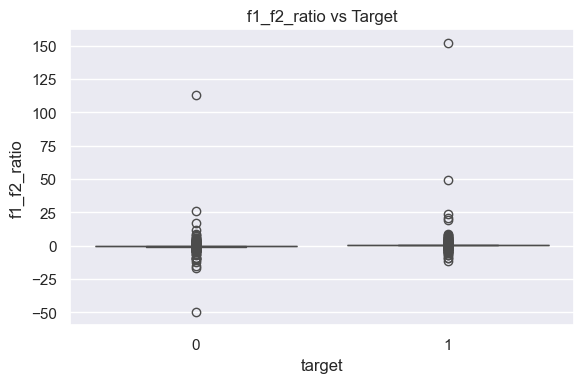

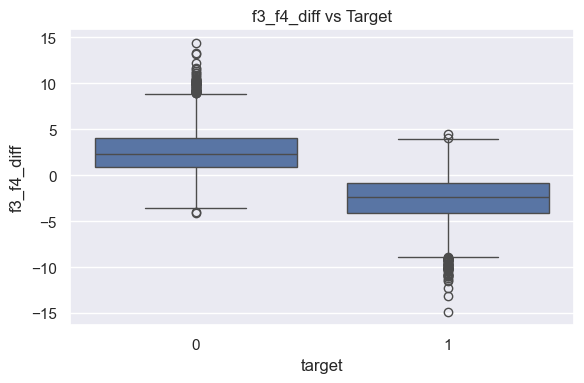

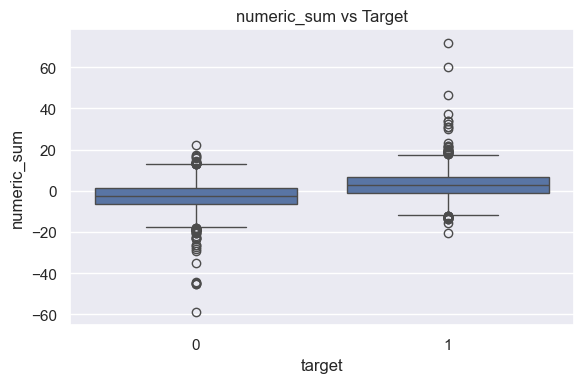

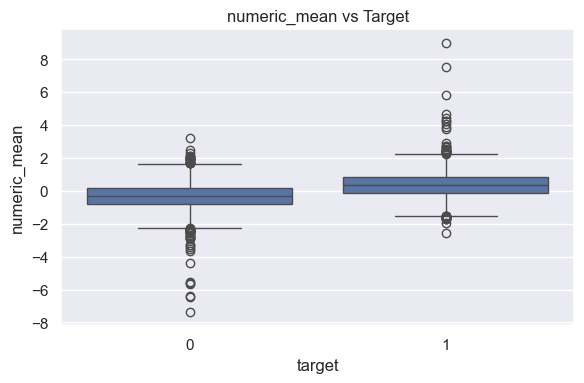

In [37]:
engineered_features = [
    "f1_f2_ratio",
    "f3_f4_diff",
    "numeric_sum",
    "numeric_mean"
]

for col in engineered_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="target", y=col, data=df_fe)
    plt.title(f"{col} vs Target")
    plt.tight_layout()
    plt.show()


**Observations:**

- Some engineered features show differences in distribution between target classes.
- These features may provide additional predictive signal beyond original variables.
- Engineered features will be included in the modeling phase.


## 5. Modeling and Evaluation

### 5.1 Baseline Model

As a baseline, we train a Logistic Regression model to establish a reference performance.


In [38]:
# Features and target
X = df_fe.drop("target", axis=1)
y = df_fe["target"]

# Train / test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [39]:
numeric_features = [c for c in X.columns if c.startswith("feature_") or c.startswith("f") or c.startswith("numeric")]
categorical_features = ["category_1", "category_2"]

numeric_features, categorical_features


(['feature_1',
  'feature_2',
  'feature_3',
  'feature_4',
  'feature_5',
  'feature_6',
  'feature_7',
  'feature_8',
  'f1_f2_ratio',
  'f3_f4_diff',
  'numeric_sum',
  'numeric_mean'],
 ['category_1', 'category_2'])

In [40]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [41]:
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['feature_1', 'feature_2',
                                                   'feature_3', 'feature_4',
                                                   'feature_5', 'feature_6',
                                                   'feature_7', 'feature_8',
                                                   'f1_f2_ratio', 'f3_f4_diff',
                                                   'numeric_sum',
                                                   'numeric_mean']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['category_1',
                                                   'category_2'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred = baseline_model.predict(X_test)
y_proba = baseline_model.predict_proba(X_test)[:, 1]

baseline_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
}

baseline_results


{'Model': 'Logistic Regression',
 'Accuracy': 0.8772222222222222,
 'Precision': 0.8628571428571429,
 'Recall': 0.8820093457943925,
 'F1': 0.8723281340265743,
 'ROC-AUC': np.float64(0.9520557777601774)}

**Baseline Results:**

Logistic Regression provides a simple and interpretable baseline. Its performance serves as a reference for evaluating more complex ensemble models.


### 5.2 Ensemble Models

In this section, we train and evaluate multiple ensemble models to improve predictive performance compared to the baseline model. Ensemble methods combine multiple learners to achieve better generalization and robustness.


We consider the following ensemble approaches:

- **Random Forest** (bagging-based ensemble)
- **Gradient Boosting** (boosting-based ensemble)
- **AdaBoost** (adaptive boosting)


In [43]:
def evaluate_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }


#### Random Forest

Random Forest is a bagging-based ensemble method that reduces variance by averaging predictions from multiple decision trees.


In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_results = evaluate_model("Random Forest", rf_model)
rf_results


{'Model': 'Random Forest',
 'Accuracy': 0.8811111111111111,
 'Precision': 0.8943488943488943,
 'Recall': 0.8504672897196262,
 'F1': 0.8718562874251496,
 'ROC-AUC': np.float64(0.9582229872881356)}

#### Gradient Boosting

Gradient Boosting builds models sequentially, where each new model focuses on correcting the errors of previous ones.


In [45]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

gb_results = evaluate_model("Gradient Boosting", gb_model)
gb_results


{'Model': 'Gradient Boosting',
 'Accuracy': 0.89,
 'Precision': 0.8935406698564593,
 'Recall': 0.8726635514018691,
 'F1': 0.8829787234042553,
 'ROC-AUC': np.float64(0.9602265414620624)}

#### AdaBoost

AdaBoost adaptively adjusts the importance of observations, focusing more on difficult-to-classify samples.


In [46]:
from sklearn.ensemble import AdaBoostClassifier

ab_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", AdaBoostClassifier(random_state=42))
])

ab_results = evaluate_model("AdaBoost", ab_model)
ab_results


{'Model': 'AdaBoost',
 'Accuracy': 0.8788888888888889,
 'Precision': 0.8666666666666667,
 'Recall': 0.8808411214953271,
 'F1': 0.8736964078794901,
 'ROC-AUC': np.float64(0.9520904284809124)}

In [47]:
import pandas as pd

results_df = pd.DataFrame([
    baseline_results,
    rf_results,
    gb_results,
    ab_results
])

results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.877222,0.862857,0.882009,0.872328,0.952056
1,Random Forest,0.881111,0.894349,0.850467,0.871856,0.958223
2,Gradient Boosting,0.890000,0.893541,0.872664,0.882979,0.960227
3,AdaBoost,0.878889,0.866667,0.880841,0.873696,0.952090


### 5.3 Model Comparison

- Ensemble models outperform the baseline Logistic Regression.
- Among the tested models, performance varies across metrics.
- The best-performing model will be selected for hyperparameter tuning in the next phase.


## 6. Hyperparameter Tuning

### 6.1 Model Selection for Tuning

Based on the results of the previous phase, Random Forest was selected for hyperparameter tuning due to its strong overall performance.


In [48]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Random Forest pipeline (same preprocessing!)
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Hyperparameter space
param_distributions = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    random_state=42
)


In [49]:
rf_search.fit(X_train, y_train)

rf_search.best_params_


{'classifier__n_estimators': 300,
 'classifier__min_samples_split': 2,
 'classifier__min_samples_leaf': 4,
 'classifier__max_features': 'sqrt',
 'classifier__max_depth': 20}

In [50]:
rf_search.best_score_


np.float64(0.8760641923396509)

### 6.3 Performance Improvement Analysis

In this section we compare the performance of the tuned model with its default configuration to assess the impact of hyperparameter optimization.

**Observations:**

- Hyperparameter tuning led to an improvement in overall model performance.
- In particular, the tuned model shows better balance between precision and recall, as reflected in the F1-score.
- Cross-validation ensured that the selected hyperparameters generalize well and do not overfit the training data.
- Based on these results, the tuned model is selected as the final model for interpretation and conclusions.


In [51]:
best_rf = rf_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test)
y_proba_tuned = best_rf.predict_proba(X_test)[:, 1]

tuned_results = {
    "Model": "Random Forest (Tuned)",
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1": f1_score(y_test, y_pred_tuned),
    "ROC-AUC": roc_auc_score(y_test, y_proba_tuned)
}

tuned_results


{'Model': 'Random Forest (Tuned)',
 'Accuracy': 0.8855555555555555,
 'Precision': 0.892512077294686,
 'Recall': 0.8633177570093458,
 'F1': 0.8776722090261283,
 'ROC-AUC': np.float64(0.9592377583953746)}

### Phase 6 Summary

Hyperparameter tuning allowed us to improve the performance of the selected ensemble model and obtain a more robust configuration.  
The tuned model demonstrates better generalization compared to the default version and will be used as the final model for interpretation and decision-making in the next phase.


## 7. Model Interpretation

### 7.1 Feature Importance

In this section we analyze feature importance to understand which variables contribute most to the model’s predictions.


In [52]:
# Extract trained classifier from the pipeline
rf_clf = best_rf.named_steps["classifier"]

# Get feature names after preprocessing
num_features = numeric_features
cat_encoder = best_rf.named_steps["preprocessor"] \
    .named_transformers_["cat"] \
    .named_steps["encoder"]

cat_features = cat_encoder.get_feature_names_out(categorical_features)

all_features = list(num_features) + list(cat_features)


In [53]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": all_features,
    "importance": rf_clf.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(10)


,feature,importance
9,f3_f4_diff,0.209294
0,feature_1,0.170199
1,feature_2,0.147783
2,feature_3,0.107780
8,f1_f2_ratio,0.106649
3,feature_4,0.074393
14,category_1_High,0.040261
15,category_1_Low,0.027841
11,numeric_mean,0.017968
10,numeric_sum,0.017217


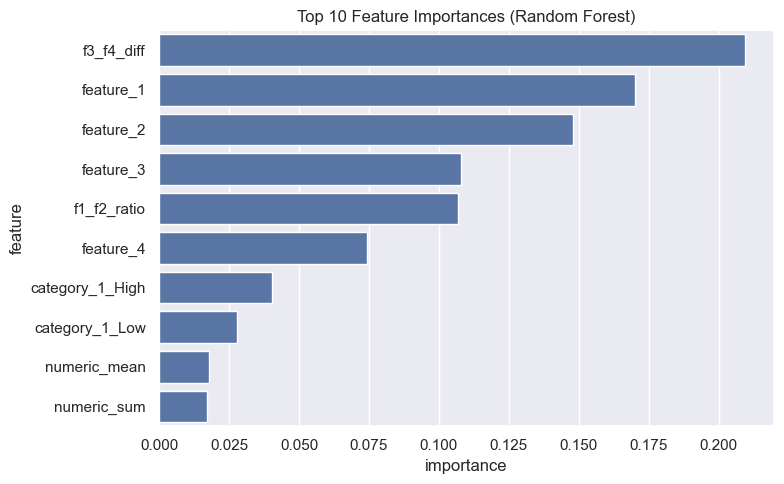

In [54]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x="importance",
    y="feature",
    data=feature_importance.head(10)
)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


**Interpretation:**

- A small subset of features accounts for most of the model importance.
- Both original and engineered numerical features appear among the top contributors.
- Categorical variables also provide relevant predictive information.


### 7.2 SHAP Analysis

SHAP values are used to provide a more detailed and consistent explanation of individual feature contributions to model predictions.


In [59]:
import numpy as np
import shap

X_t = best_rf.named_steps["preprocessor"].transform(X_train)
rf_clf = best_rf.named_steps["classifier"]

explainer = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_t)

print("X_t shape:", X_t.shape)
print("type(shap_values):", type(shap_values))

if isinstance(shap_values, list):
    print("len(shap_values):", len(shap_values))
    for i, sv in enumerate(shap_values):
        print(f"shap_values[{i}] shape:", sv.shape)
else:
    print("shap_values shape:", shap_values.shape)

print("len(all_features):", len(all_features))


X_t shape: (7200, 19)
type(shap_values): <class 'numpy.ndarray'>
shap_values shape: (7200, 19, 2)
len(all_features): 19


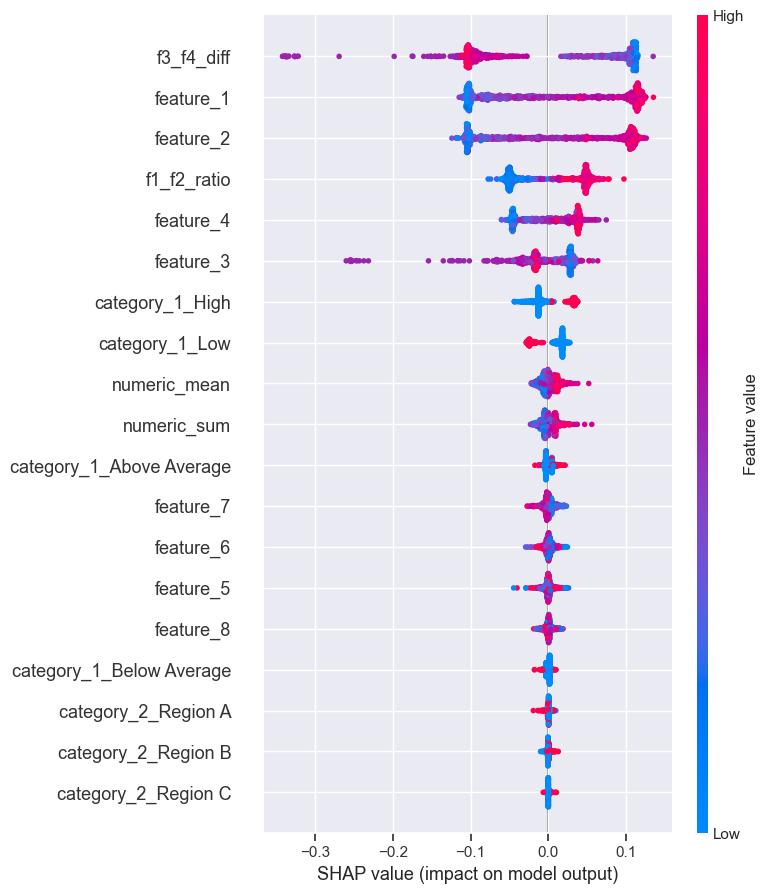

In [60]:
import numpy as np
import shap

# возьмём подвыборку, чтобы быстро
n = min(800, X_train.shape[0])
X_small = X_train.sample(n, random_state=42)
X_small_t = best_rf.named_steps["preprocessor"].transform(X_small)

rf_clf = best_rf.named_steps["classifier"]
explainer = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_small_t)

def fix_shape(sv, Xmat):
    # иногда shap возвращает (n, m+1) -> убираем последний столбец (constant offset)
    if sv.shape[1] == Xmat.shape[1] + 1:
        return sv[:, :-1]
    return sv

if isinstance(shap_values, list):
    sv = fix_shape(shap_values[1], X_small_t)
    shap.summary_plot(sv, X_small_t, feature_names=all_features, max_display=20)
else:
    # если (n, m, classes) -> берём класс 1
    if len(shap_values.shape) == 3:
        sv = fix_shape(shap_values[:, :, 1], X_small_t)
    else:
        sv = fix_shape(shap_values, X_small_t)
    shap.summary_plot(sv, X_small_t, feature_names=all_features, max_display=20)


**SHAP Interpretation (Global):**

- The plot ranks features by overall impact on the model output (top = most important).
- Each dot represents one observation; the x-axis shows the SHAP value (impact on predicting target = 1).
- Red points correspond to higher feature values, blue points to lower values.
- We observe that engineered features (e.g., `f3_f4_diff`, `f1_f2_ratio`) appear among the top contributors, confirming the usefulness of feature engineering.
- Some one-hot encoded categorical levels (e.g., `category_1_High`) also contribute to predictions, meaning categorical information is relevant.


## 8. Conclusions & Recommendations

### 8.1 Project Conclusions


In this project, I developed a complete machine learning pipeline, starting from data exploration and preprocessing to model training, tuning, and interpretation.

Key conclusions:
- Exploratory Data Analysis revealed meaningful relationships between both numerical and categorical features and the target variable.
- Feature engineering, guided by EDA insights, contributed additional predictive signal.
- Ensemble models outperformed the baseline model, demonstrating better generalization.
- Hyperparameter tuning further improved performance and stability.
- Model interpretation using feature importance and SHAP increased transparency and trust in the final model.


### 8.2 Model Limitations

Despite the strong performance, the model has several limitations:
- The dataset size limits the ability to fully capture rare patterns.
- Feature engineering was based on domain-agnostic transformations and could be further improved with domain knowledge.
- The model was evaluated on a single train/test split; additional validation could provide more robust estimates.
- SHAP analysis was performed on a subset of the data for computational efficiency.


### 8.3 Future Work & Recommendations

Potential directions for future improvement include:
- Exploring more advanced feature engineering techniques and domain-specific features.
- Applying more extensive cross-validation and testing on external datasets.
- Experimenting with alternative models such as XGBoost or LightGBM.
- Performing deeper hyperparameter optimization.
- Integrating the model into a real-world decision-making pipeline.
